In [1]:
# importing required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
import seaborn as sns

# 1. Loading the dataset

In [2]:
url = "https://raw.githubusercontent.com/Shubhajeetgithub/ML-Lab-Data/refs/heads/main/original_texture_data.csv"
df = pd.read_csv(url)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Class
0,-1.223,-0.798,-0.867,-0.639,-0.545,-0.412,-0.795,-0.629,-0.547,-0.868,...,-0.766,-0.555,-0.714,-0.545,-0.587,-0.871,-0.620,-0.568,-0.607,5
1,-1.410,-1.029,-1.013,-0.895,-0.762,-0.676,-1.043,-0.851,-0.775,-1.037,...,-0.919,-0.770,-0.847,-0.663,-0.723,-1.013,-0.748,-0.698,-0.817,5
2,-1.107,-0.649,-0.629,-0.492,-0.367,-0.298,-0.682,-0.478,-0.395,-0.681,...,-0.692,-0.445,-0.588,-0.371,-0.368,-0.746,-0.457,-0.379,-0.469,5
3,-1.270,-0.855,-0.958,-0.707,-0.619,-0.469,-0.872,-0.705,-0.620,-0.988,...,-0.829,-0.719,-0.774,-0.617,-0.688,-0.937,-0.693,-0.657,-0.779,5
4,-1.331,-0.862,-0.761,-0.689,-0.498,-0.361,-0.857,-0.600,-0.496,-0.779,...,-0.861,-0.571,-0.784,-0.545,-0.562,-0.952,-0.642,-0.578,-0.648,5


# 2. Showing the class distribution

In [3]:
class_distribution = df['Class'].value_counts()
print("Class Distribution:")
print(class_distribution)

Class Distribution:
Class
5     500
6     500
7     500
11    500
1     500
9     500
8     500
10    500
2     500
3     500
4     500
Name: count, dtype: int64


Each class has exactly 500 instances, so the class distribution is perfectly balanced.

# 3. Splitting into training and testing

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Designing a Gaussian Naive Bayes’ (NB) classifier and fitting it on the training set

In [6]:
class GaussianNaiveBayes:
    def __init__(self):
        self.classes = None
        self.class_priors = None
        self.class_means = None
        self.class_variances = None

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_features = X.shape[1]

        self.class_priors = np.zeros(n_classes)
        self.class_means = np.zeros((n_classes, n_features))
        self.class_variances = np.zeros((n_classes, n_features))

        for i, c in enumerate(self.classes):
            X_c = X[y == c]
            self.class_priors[i] = X_c.shape[0] / X.shape[0]
            self.class_means[i, :] = np.mean(X_c, axis=0)
            self.class_variances[i, :] = np.var(X_c, axis=0) + 1e-9 # Add a small value for numerical stability

    def predict(self, X):
        y_pred = []
        for x in X:
            posteriors = []
            for i, c in enumerate(self.classes):
                prior = np.log(self.class_priors[i])
                likelihood = np.sum(np.log(self.pdf(i, x)))
                posterior = prior + likelihood
                posteriors.append(posterior)
            y_pred.append(self.classes[np.argmax(posteriors)])
        return np.array(y_pred)

    def pdf(self, class_idx, x):
        mean = self.class_means[class_idx, :]
        variance = self.class_variances[class_idx, :]
        numerator = np.exp(-((x - mean) ** 2) / (2 * variance))
        denominator = np.sqrt(2 * np.pi * variance)
        return numerator / denominator

In [7]:
custom_nb_classifier = GaussianNaiveBayes()

# Fitting the classifier on the scaled training data
custom_nb_classifier.fit(X_train_scaled, y_train)

# 6. Evaluation

Accuracy: 0.7818
Precision: 0.7857
Recall: 0.7818


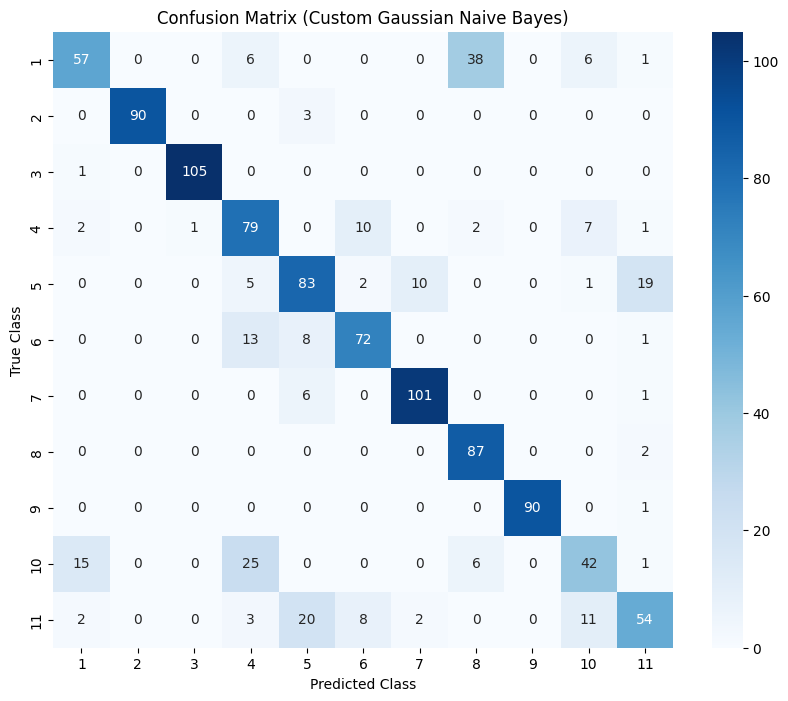

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the scaled test data
y_pred_custom_nb = custom_nb_classifier.predict(X_test_scaled)

# Evaluate the performance
accuracy = accuracy_score(y_test, y_pred_custom_nb)
precision = precision_score(y_test, y_pred_custom_nb, average='weighted')
recall = recall_score(y_test, y_pred_custom_nb, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred_custom_nb)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Display the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=custom_nb_classifier.classes, yticklabels=custom_nb_classifier.classes)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix (Custom Gaussian Naive Bayes)')
plt.show()

# 7. Using scikit-learn's implementation of Gaussian NB classifier

In [9]:
from sklearn.naive_bayes import GaussianNB

# Initializing the Gaussian Naive Bayes classifier
sklearn_nb_classifier = GaussianNB()

# Fitting the classifier on the scaled training data
sklearn_nb_classifier.fit(X_train_scaled, y_train)

GaussianNB()

In [10]:
# Making predictions on the scaled test data using scikit-learn's GaussianNB
y_pred_sklearn_nb = sklearn_nb_classifier.predict(X_test_scaled)

# 8. Evaluation and comparison of Scikit learn model with custom implementation

scikit-learn Gaussian Naive Bayes Performance:
Accuracy: 0.7818
Precision: 0.7857
Recall: 0.7818


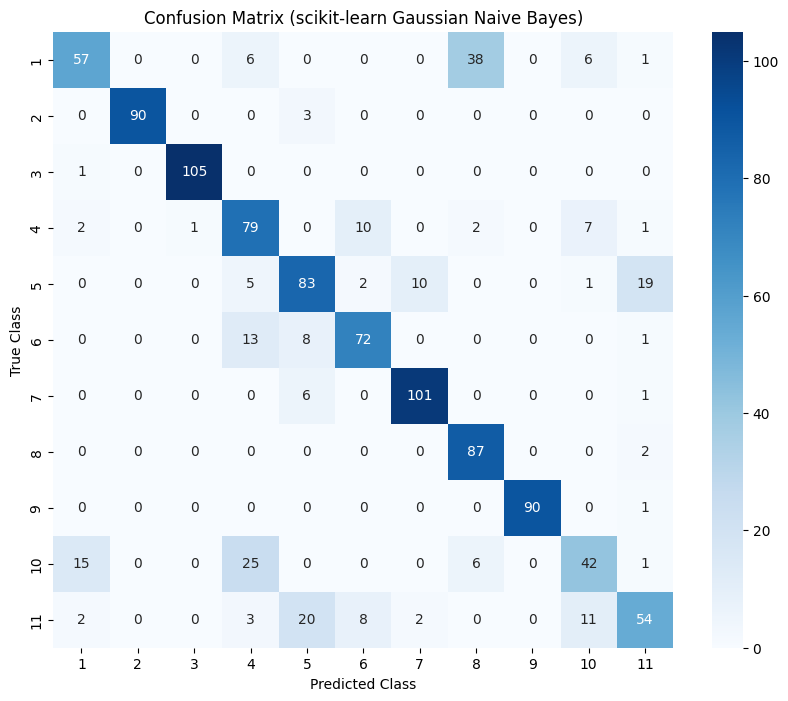

In [11]:
# Evaluation of the performance of the scikit-learn model
sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn_nb)
sklearn_precision = precision_score(y_test, y_pred_sklearn_nb, average='weighted')
sklearn_recall = recall_score(y_test, y_pred_sklearn_nb, average='weighted')
sklearn_conf_matrix = confusion_matrix(y_test, y_pred_sklearn_nb)

print(f"scikit-learn Gaussian Naive Bayes Performance:")
print(f"Accuracy: {sklearn_accuracy:.4f}")
print(f"Precision: {sklearn_precision:.4f}")
print(f"Recall: {sklearn_recall:.4f}")

# Displaying the confusion matrix for scikit-learn model
plt.figure(figsize=(10, 8))
sns.heatmap(sklearn_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=custom_nb_classifier.classes, yticklabels=custom_nb_classifier.classes)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix (scikit-learn Gaussian Naive Bayes)')
plt.show()

In [12]:
# Comparison
print("Performance Comparison:")
print("-" * 30)
print(f"{'Metric':<15} | {'Custom NB':<15} | {'Scikit-learn NB':<15}")
print("-" * 60)
print(f"{'Accuracy':<15} | {accuracy:<15.4f} | {sklearn_accuracy:<15.4f}")
print(f"{'Precision':<15} | {precision:<15.4f} | {sklearn_precision:<15.4f}")
print(f"{'Recall':<15} | {recall:<15.4f} | {sklearn_recall:<15.4f}")
print("-" * 60)

print("\nResults on Performance Comparison:")
if abs(accuracy - sklearn_accuracy) < 1e-6 and \
   abs(precision - sklearn_precision) < 1e-6 and \
   abs(recall - sklearn_recall) < 1e-6:
    print("The performance metrics (Accuracy, Precision, and Recall) for the custom Gaussian Naive Bayes classifier are very similar to those of the scikit-learn implementation.")
else:
    print("There are notable differences in the performance metrics (Accuracy, Precision, or Recall) between the custom Gaussian Naive Bayes classifier and the scikit-learn implementation.")


Performance Comparison:
------------------------------
Metric          | Custom NB       | Scikit-learn NB
------------------------------------------------------------
Accuracy        | 0.7818          | 0.7818         
Precision       | 0.7857          | 0.7857         
Recall          | 0.7818          | 0.7818         
------------------------------------------------------------

Results on Performance Comparison:
The performance metrics (Accuracy, Precision, and Recall) for the custom Gaussian Naive Bayes classifier are very similar to those of the scikit-learn implementation.
